In [ ]:
# Cell 1: Install and Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Cell 2: Load and Explore Data
# Upload the dataset to Colab first, then update the path
df = pd.read_csv('/content/energy_data_II.csv')  # Update path as needed

print("Dataset shape:", df.shape)
print("\nDataset info:")
print(df.info())
print("\nFirst few rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())
print("\nTarget variable statistics:")
print(df['CO2 emissions (kt)'].describe())

Dataset shape: (2926, 54)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2926 entries, 0 to 2925
Data columns (total 54 columns):
 #   Column                                                                                                                             Non-Null Count  Dtype  
---  ------                                                                                                                             --------------  -----  
 0   Country Name                                                                                                                       2926 non-null   object 
 1   Country Code                                                                                                                       2926 non-null   object 
 2   Years                                                                                                                              2926 non-null   int64  
 3   Access to clean fuels and technologies for cook

In [ ]:
# Cell 3: Data Preprocessing
# Remove rows with missing target values
df_clean = df.dropna(subset=['CO2 emissions (kt)'])

# Select only numeric columns for features
numeric_columns = df_clean.select_dtypes(include=[np.number]).columns.tolist()

# Remove the target variable from features
if 'CO2 emissions (kt)' in numeric_columns:
    numeric_columns.remove('CO2 emissions (kt)')

# Prepare features and target
X = df_clean[numeric_columns].fillna(df_clean[numeric_columns].mean())
y = df_clean['CO2 emissions (kt)']

print(f"Number of features: {X.shape[1]}")
print(f"Feature columns: {list(X.columns)}")
print(f"Dataset shape after cleaning: {X.shape}")
print(f"Target variable shape: {y.shape}")

Number of features: 51
Feature columns: ['Years', 'Access to clean fuels and technologies for cooking (% of population)', 'Access to clean fuels and technologies for cooking, rural (% of rural population)', 'Access to clean fuels and technologies for cooking, urban (% of urban population)', 'Access to electricity (% of population)', 'Access to electricity, rural (% of rural population)', 'Access to electricity, urban (% of urban population)', 'Adjusted savings: energy depletion (% of GNI)', 'Alternative and nuclear energy (% of total energy use)', 'CO2 emissions (metric tons per capita)', 'CO2 emissions from electricity and heat production, total (% of total fuel combustion)', 'CO2 emissions from gaseous fuel consumption (% of total)', 'CO2 emissions from gaseous fuel consumption (kt)', 'CO2 emissions from liquid fuel consumption (% of total)', 'CO2 emissions from liquid fuel consumption (kt)', 'CO2 emissions from manufacturing industries and construction (% of total fuel combustion)',

In [ ]:
# Cell 4: Train-Test Split and Scaling
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (essential for PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")
print(f"Features are now standardized for PCA")

Training set shape: (1911, 51)
Test set shape: (478, 51)
Features are now standardized for PCA


Total number of original features: 51
Components needed for 95% variance: 27
Original feature space: 51 dimensions
Reduced feature space: 27 dimensions
Variance retained: 0.9546


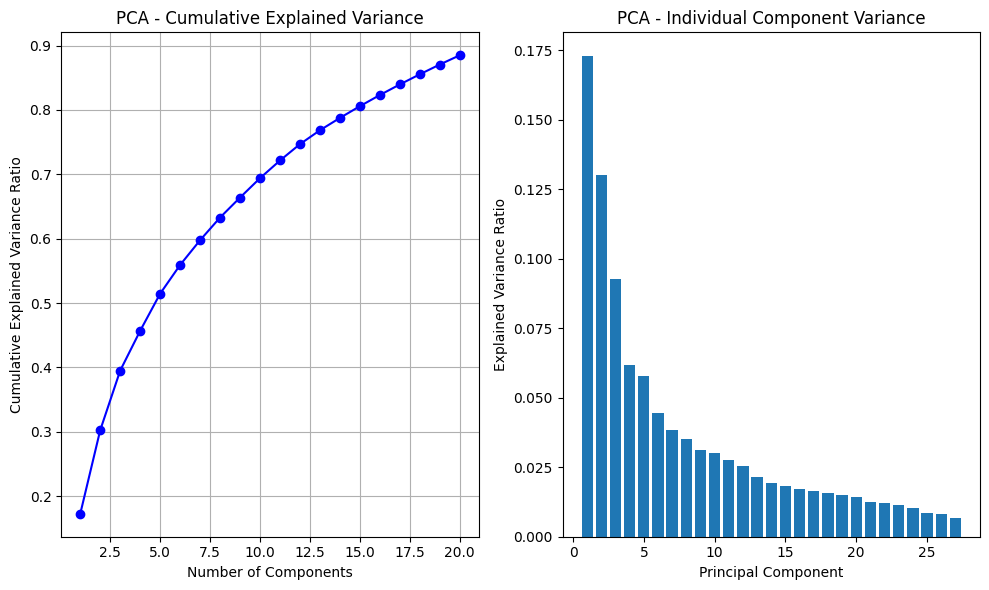

In [ ]:
# Cell 5: Apply PCA
# Determine optimal number of components (explained variance)
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Total number of original features: {X_train_scaled.shape[1]}")
print(f"Components needed for 95% variance: {n_components_95}")

# Apply PCA with optimal components
pca = PCA(n_components=n_components_95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original feature space: {X_train_scaled.shape[1]} dimensions")
print(f"Reduced feature space: {X_train_pca.shape[1]} dimensions")
print(f"Variance retained: {sum(pca.explained_variance_ratio_):.4f}")

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(cumulative_variance[:20]) + 1), cumulative_variance[:20], 'bo-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('PCA - Cumulative Explained Variance')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA - Individual Component Variance')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 6: Model Training and Prediction
# Train models on both original and PCA-transformed data
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for model_name, model in models.items():
    # Train on original data
    model_orig = model
    model_orig.fit(X_train_scaled, y_train)
    y_pred_orig = model_orig.predict(X_test_scaled)

    # Train on PCA data
    model_pca = type(model)() if model_name == 'Linear Regression' else type(model)(n_estimators=100, random_state=42)
    model_pca.fit(X_train_pca, y_train)
    y_pred_pca = model_pca.predict(X_test_pca)

    results[model_name] = {
        'original': {'predictions': y_pred_orig, 'model': model_orig},
        'pca': {'predictions': y_pred_pca, 'model': model_pca}
    }

print("Models trained successfully on both original and PCA-transformed data!")

Models trained successfully on both original and PCA-transformed data!


In [ ]:
# Cell 7: Calculate Metrics
def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2_Score': r2,
        'Accuracy': max(0, r2 * 100)  # R² as accuracy percentage
    }

# Calculate metrics for all models
metrics_comparison = {}

for model_name in models.keys():
    metrics_comparison[model_name] = {}

    # Original data metrics
    orig_metrics = calculate_metrics(y_test, results[model_name]['original']['predictions'])
    metrics_comparison[model_name]['Original'] = orig_metrics

    # PCA data metrics
    pca_metrics = calculate_metrics(y_test, results[model_name]['pca']['predictions'])
    metrics_comparison[model_name]['PCA'] = pca_metrics

# Display results
for model_name in metrics_comparison:
    print(f"\n{'='*50}")
    print(f"MODEL: {model_name}")
    print(f"{'='*50}")

    for data_type in ['Original', 'PCA']:
        print(f"\n{data_type} Data:")
        metrics = metrics_comparison[model_name][data_type]
        print(f"  Accuracy (R² Score): {metrics['Accuracy']:.2f}%")
        print(f"  RMSE: {metrics['RMSE']:.2f}")
        print(f"  MAE: {metrics['MAE']:.2f}")
        print(f"  R² Score: {metrics['R2_Score']:.4f}")


MODEL: Linear Regression

Original Data:
  Accuracy (R² Score): 99.97%
  RMSE: 62585.82
  MAE: 38267.87
  R² Score: 0.9997

PCA Data:
  Accuracy (R² Score): 91.78%
  RMSE: 1081305.74
  MAE: 634648.10
  R² Score: 0.9178

MODEL: Random Forest

Original Data:
  Accuracy (R² Score): 99.59%
  RMSE: 242250.24
  MAE: 36716.91
  R² Score: 0.9959

PCA Data:
  Accuracy (R² Score): 96.20%
  RMSE: 735313.45
  MAE: 247077.46
  R² Score: 0.9620


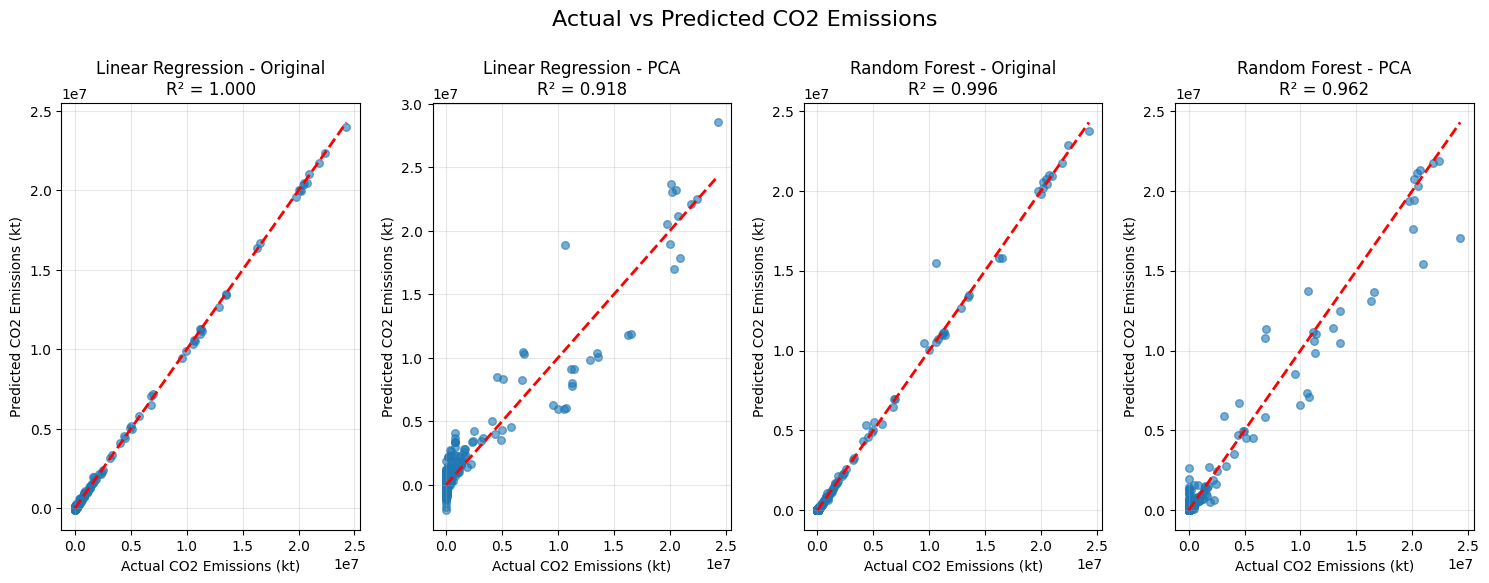

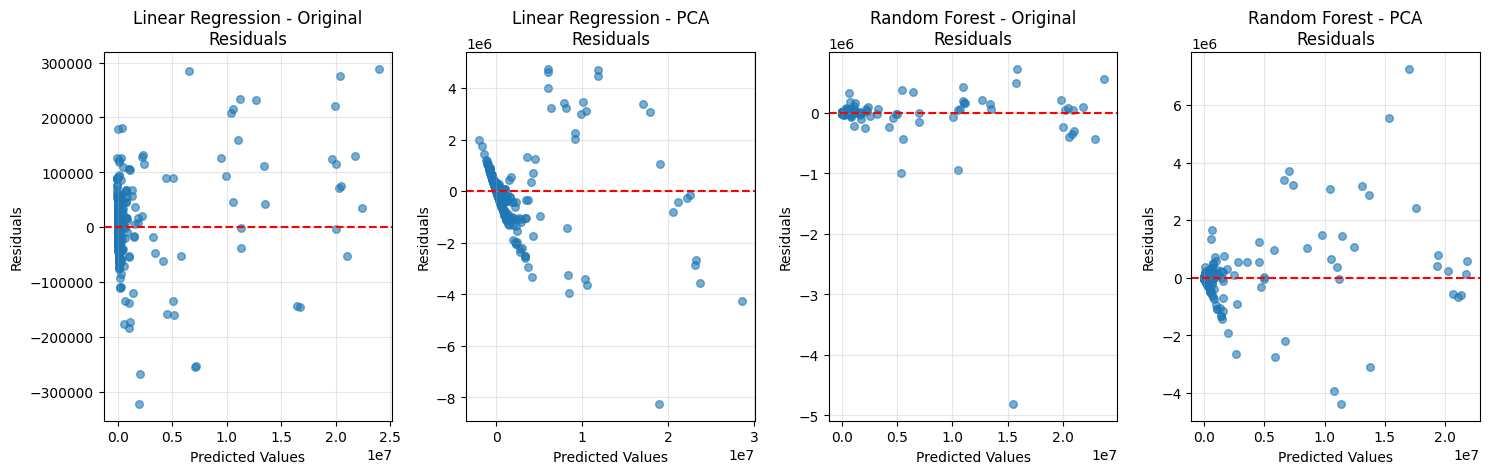

In [ ]:
# Cell 8: Actual vs Predicted Plots
plt.figure(figsize=(15, 10))

plot_idx = 1
for model_name in models.keys():
    for data_type in ['Original', 'PCA']:
        plt.subplot(2, 4, plot_idx)

        y_pred = results[model_name][data_type.lower()]['predictions']

        plt.scatter(y_test, y_pred, alpha=0.6, s=30)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

        r2 = metrics_comparison[model_name][data_type]['R2_Score']
        plt.title(f'{model_name} - {data_type}\nR² = {r2:.3f}')
        plt.xlabel('Actual CO2 Emissions (kt)')
        plt.ylabel('Predicted CO2 Emissions (kt)')
        plt.grid(True, alpha=0.3)

        plot_idx += 1

plt.tight_layout()
plt.suptitle('Actual vs Predicted CO2 Emissions', fontsize=16, y=1.02)
plt.show()

# Residual plots
plt.figure(figsize=(15, 5))
plot_idx = 1

for model_name in models.keys():
    for data_type in ['Original', 'PCA']:
        plt.subplot(1, 4, plot_idx)

        y_pred = results[model_name][data_type.lower()]['predictions']
        residuals = y_test - y_pred

        plt.scatter(y_pred, residuals, alpha=0.6, s=30)
        plt.axhline(y=0, color='r', linestyle='--')
        plt.title(f'{model_name} - {data_type}\nResiduals')
        plt.xlabel('Predicted Values')
        plt.ylabel('Residuals')
        plt.grid(True, alpha=0.3)

        plot_idx += 1

plt.tight_layout()
plt.show()

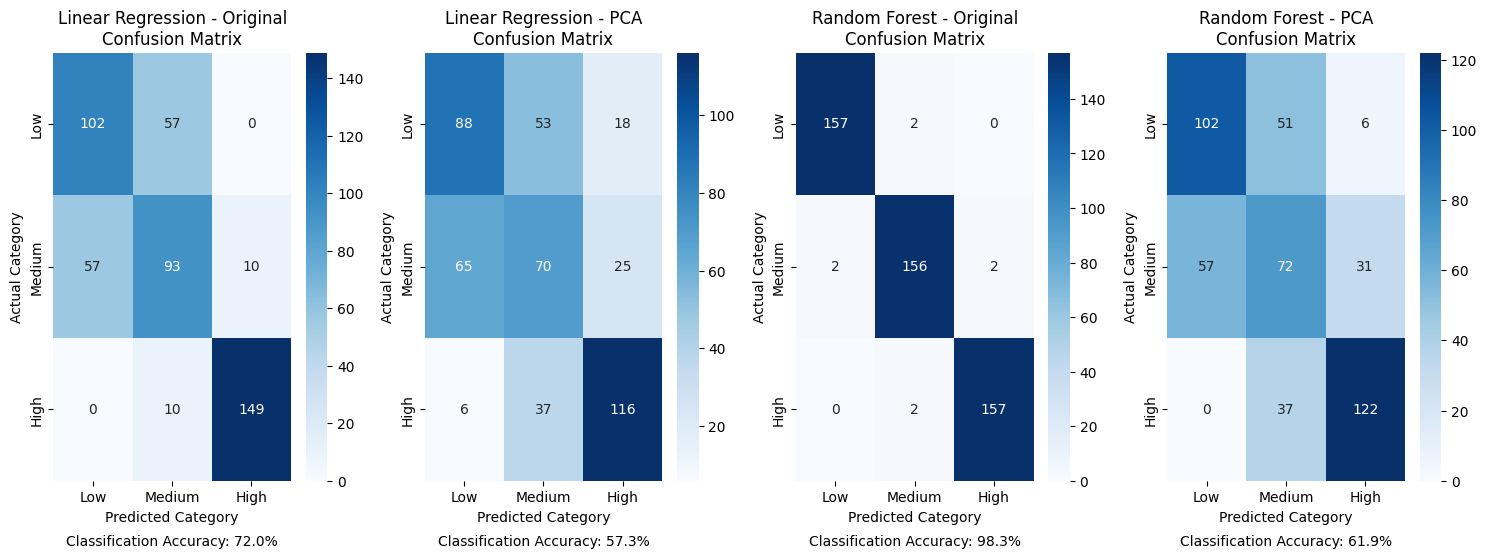

In [ ]:
# Cell 9: Confusion Matrix (Converting regression to classification)
# Convert continuous CO2 emissions to categories for confusion matrix
def create_co2_categories(values):
    """Convert CO2 emissions to categorical labels"""
    percentiles = np.percentile(values, [33.33, 66.67])
    categories = np.zeros(len(values))
    categories[values <= percentiles[0]] = 0  # Low
    categories[(values > percentiles[0]) & (values <= percentiles[1])] = 1  # Medium
    categories[values > percentiles[1]] = 2  # High
    return categories.astype(int)

# Convert actual and predicted values to categories
y_test_cat = create_co2_categories(y_test)

plt.figure(figsize=(15, 10))

plot_idx = 1
category_names = ['Low', 'Medium', 'High']

for model_name in models.keys():
    for data_type in ['Original', 'PCA']:
        plt.subplot(2, 4, plot_idx)

        y_pred = results[model_name][data_type.lower()]['predictions']
        y_pred_cat = create_co2_categories(y_pred)

        cm = confusion_matrix(y_test_cat, y_pred_cat)

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=category_names, yticklabels=category_names)
        plt.title(f'{model_name} - {data_type}\nConfusion Matrix')
        plt.xlabel('Predicted Category')
        plt.ylabel('Actual Category')

        # Calculate classification accuracy
        class_accuracy = np.trace(cm) / np.sum(cm) * 100
        plt.text(0.5, -0.15, f'Classification Accuracy: {class_accuracy:.1f}%',
                transform=plt.gca().transAxes, ha='center')

        plot_idx += 1

plt.tight_layout()
plt.show()

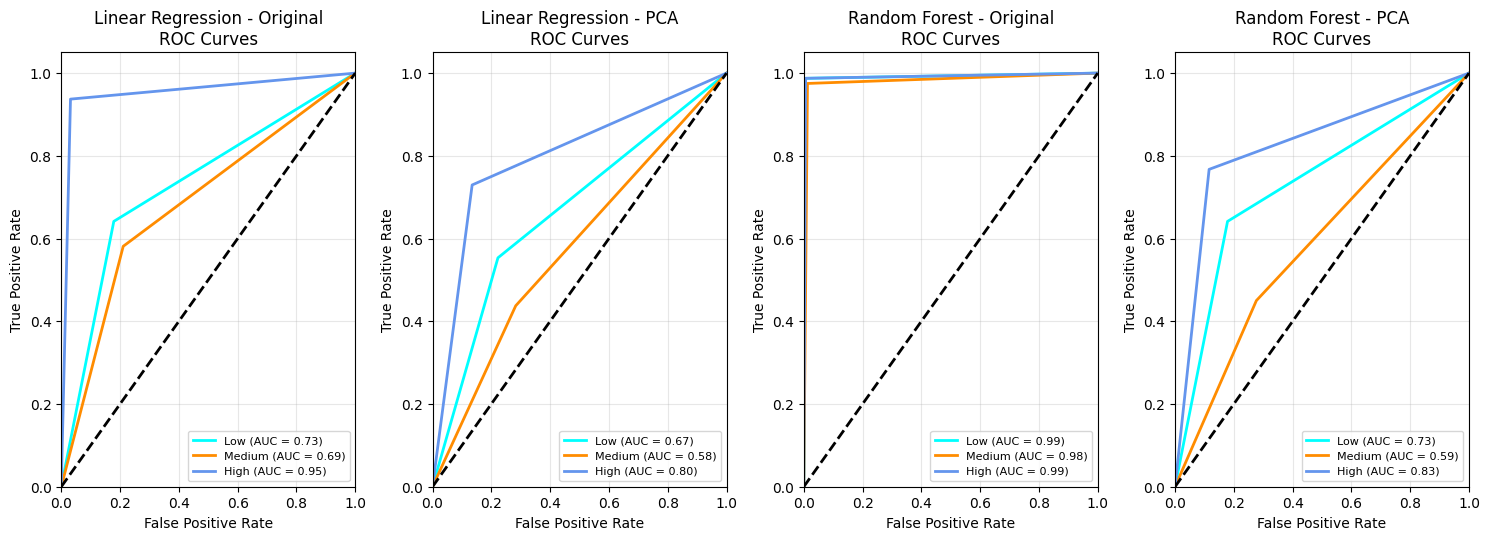

In [ ]:
# Cell 10: ROC Curves (Multi-class)
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc
from itertools import cycle

plt.figure(figsize=(15, 10))

colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
plot_idx = 1

for model_name in models.keys():
    for data_type in ['Original', 'PCA']:
        plt.subplot(2, 4, plot_idx)

        y_pred = results[model_name][data_type.lower()]['predictions']
        y_pred_cat = create_co2_categories(y_pred)

        # Binarize the labels for multi-class ROC
        lb = LabelBinarizer()
        y_test_bin = lb.fit_transform(y_test_cat)
        y_pred_bin = lb.transform(y_pred_cat)

        # Compute ROC curve and AUC for each class
        fpr = dict()
        tpr = dict()
        roc_auc = dict()

        for i in range(3):  # 3 classes
            if len(np.unique(y_test_bin[:, i])) > 1:  # Check if class exists
                fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
                roc_auc[i] = auc(fpr[i], tpr[i])
            else:
                roc_auc[i] = 0.5  # Default AUC for missing class

        # Plot ROC curves
        colors_list = ['aqua', 'darkorange', 'cornflowerblue']
        for i, color in zip(range(3), colors_list):
            if i in fpr:
                plt.plot(fpr[i], tpr[i], color=color, lw=2,
                        label=f'{category_names[i]} (AUC = {roc_auc[i]:.2f})')

        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{model_name} - {data_type}\nROC Curves')
        plt.legend(loc="lower right", fontsize=8)
        plt.grid(True, alpha=0.3)

        plot_idx += 1

plt.tight_layout()
plt.show()

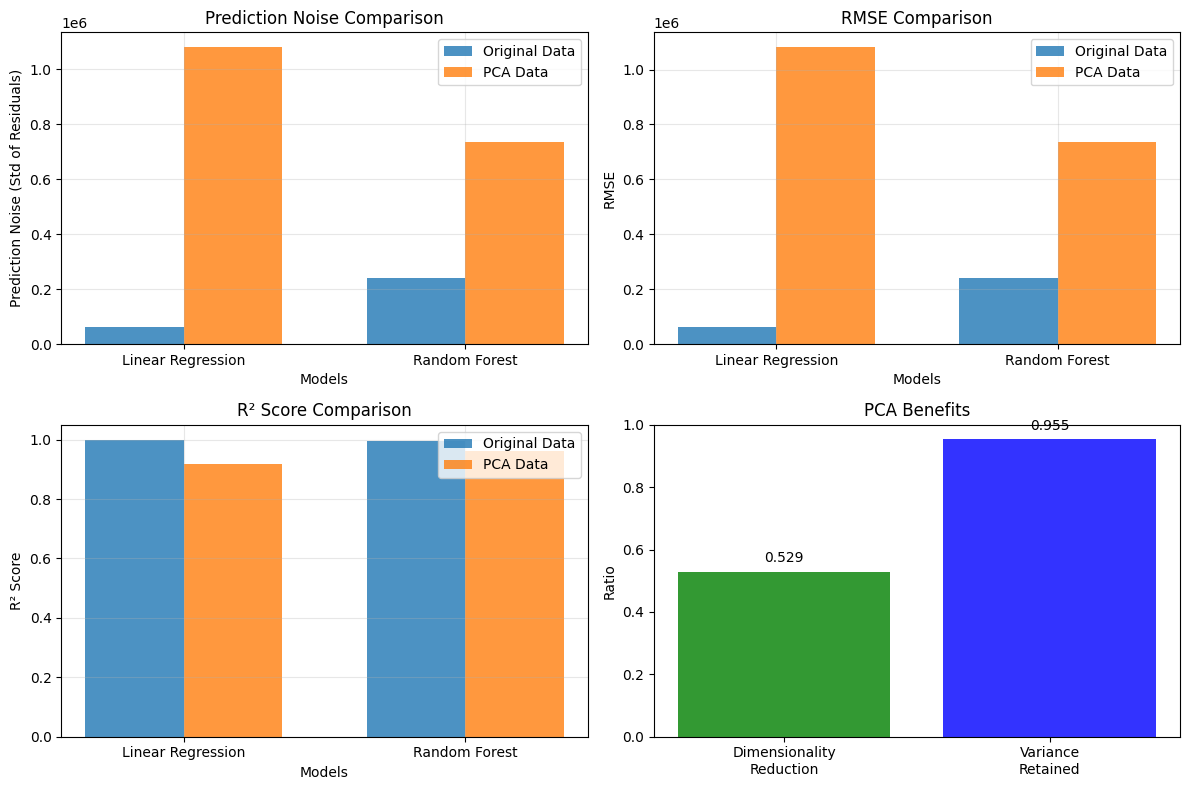


FINAL PCA ANALYSIS SUMMARY
Original Dimensions: 51
Reduced Dimensions: 27
Dimensionality Reduction: 47.1%
Variance Retained: 95.5%

Best Performing Model:
  Model: Linear Regression
  Data Type: Original
  R² Score: 0.9997
  Accuracy: 99.97%


In [ ]:
# Cell 11: Noise Analysis and Final Summary
# Noise analysis - comparing prediction variance
plt.figure(figsize=(12, 8))

# Calculate prediction noise (standard deviation of residuals)
noise_analysis = {}

for model_name in models.keys():
    noise_analysis[model_name] = {}

    for data_type in ['Original', 'PCA']:
        y_pred = results[model_name][data_type.lower()]['predictions']
        residuals = y_test - y_pred
        noise = np.std(residuals)
        noise_analysis[model_name][data_type] = noise

# Plot noise comparison
plt.subplot(2, 2, 1)
models_list = list(models.keys())
original_noise = [noise_analysis[model]['Original'] for model in models_list]
pca_noise = [noise_analysis[model]['PCA'] for model in models_list]

x = np.arange(len(models_list))
width = 0.35

plt.bar(x - width/2, original_noise, width, label='Original Data', alpha=0.8)
plt.bar(x + width/2, pca_noise, width, label='PCA Data', alpha=0.8)

plt.xlabel('Models')
plt.ylabel('Prediction Noise (Std of Residuals)')
plt.title('Prediction Noise Comparison')
plt.xticks(x, models_list)
plt.legend()
plt.grid(True, alpha=0.3)

# Error comparison
plt.subplot(2, 2, 2)
original_rmse = [metrics_comparison[model]['Original']['RMSE'] for model in models_list]
pca_rmse = [metrics_comparison[model]['PCA']['RMSE'] for model in models_list]

plt.bar(x - width/2, original_rmse, width, label='Original Data', alpha=0.8)
plt.bar(x + width/2, pca_rmse, width, label='PCA Data', alpha=0.8)

plt.xlabel('Models')
plt.ylabel('RMSE')
plt.title('RMSE Comparison')
plt.xticks(x, models_list)
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy comparison
plt.subplot(2, 2, 3)
original_r2 = [metrics_comparison[model]['Original']['R2_Score'] for model in models_list]
pca_r2 = [metrics_comparison[model]['PCA']['R2_Score'] for model in models_list]

plt.bar(x - width/2, original_r2, width, label='Original Data', alpha=0.8)
plt.bar(x + width/2, pca_r2, width, label='PCA Data', alpha=0.8)

plt.xlabel('Models')
plt.ylabel('R² Score')
plt.title('R² Score Comparison')
plt.xticks(x, models_list)
plt.legend()
plt.grid(True, alpha=0.3)

# Dimensionality reduction benefit
plt.subplot(2, 2, 4)
reduction_ratio = X_train_pca.shape[1] / X_train_scaled.shape[1]
variance_retained = sum(pca.explained_variance_ratio_)

plt.bar(['Dimensionality\nReduction'], [reduction_ratio], alpha=0.8, color='green')
plt.bar(['Variance\nRetained'], [variance_retained], alpha=0.8, color='blue')

plt.ylabel('Ratio')
plt.title('PCA Benefits')
plt.ylim([0, 1])
for i, v in enumerate([reduction_ratio, variance_retained]):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Final Summary
print("\n" + "="*60)
print("FINAL PCA ANALYSIS SUMMARY")
print("="*60)
print(f"Original Dimensions: {X_train_scaled.shape[1]}")
print(f"Reduced Dimensions: {X_train_pca.shape[1]}")
print(f"Dimensionality Reduction: {(1 - reduction_ratio)*100:.1f}%")
print(f"Variance Retained: {variance_retained*100:.1f}%")

print(f"\nBest Performing Model:")
best_model = max(metrics_comparison.keys(),
                key=lambda x: max(metrics_comparison[x]['Original']['R2_Score'],
                                 metrics_comparison[x]['PCA']['R2_Score']))
best_data_type = 'PCA' if metrics_comparison[best_model]['PCA']['R2_Score'] > metrics_comparison[best_model]['Original']['R2_Score'] else 'Original'
best_r2 = metrics_comparison[best_model][best_data_type]['R2_Score']

print(f"  Model: {best_model}")
print(f"  Data Type: {best_data_type}")
print(f"  R² Score: {best_r2:.4f}")
print(f"  Accuracy: {best_r2*100:.2f}%")